In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Eval train time line

In [3]:
eval_test_time = [1600, 3200, 4800, 6400, 8000]
m_5_1 = [0.1574, 0.2135, 0.2126, 0.2271, 0.2332]
m_5_5 = [0.2485, 0.2967, 0.3145, 0.3040, 0.3173]
m_10_1 = [0.1384, 0.1592, 0.1628, 0.1639, 0.1688]
m_10_5 = [0.2110, 0.2286, 0.2480, 0.2531, 0.2433]

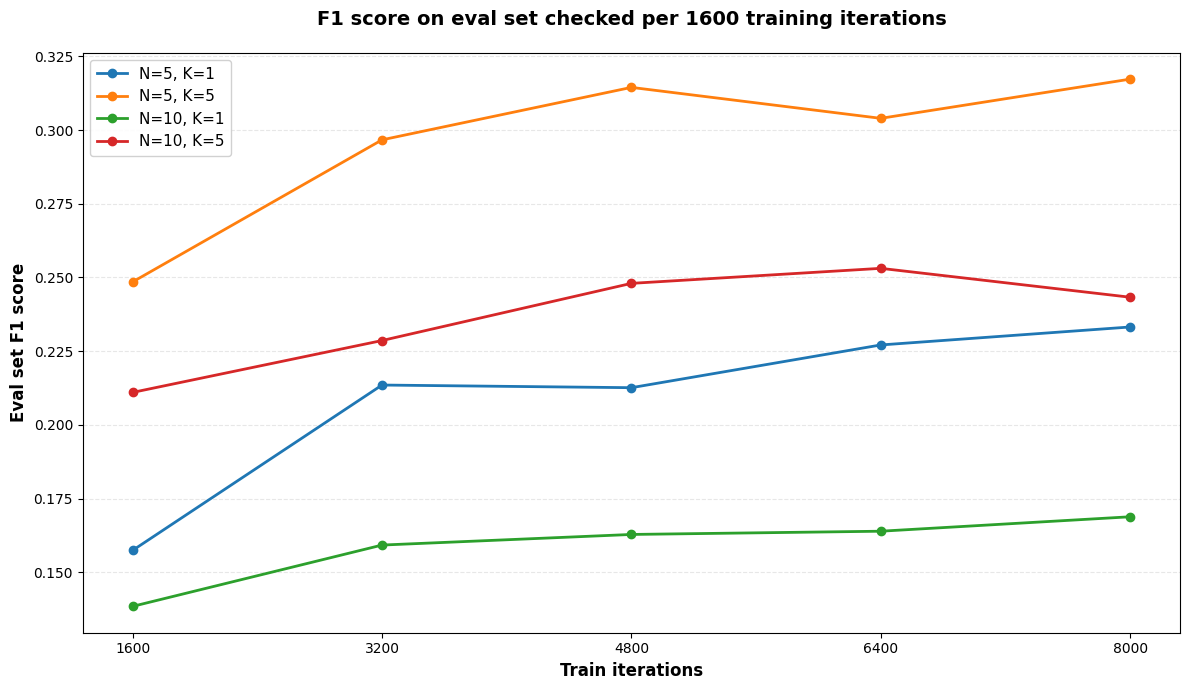

In [35]:
plt.figure(figsize=(12, 7))
plt.plot(eval_test_time, m_5_1, marker="o", label="N=5, K=1", linewidth=2)
plt.plot(eval_test_time, m_5_5, marker="o", label="N=5, K=5", linewidth=2)
plt.plot(eval_test_time, m_10_1, marker="o", label="N=10, K=1", linewidth=2)
plt.plot(eval_test_time, m_10_5, marker="o", label="N=10, K=5", linewidth=2)
plt.xticks(eval_test_time)
plt.xlabel("Train iterations", fontsize=12, fontweight="bold")
plt.ylabel("Eval set F1 score", fontsize=12, fontweight="bold")
plt.title("F1 score on eval set checked per 1600 training iterations", fontsize=14, fontweight="bold", pad=20)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

## EDA

In [14]:
df_5_1 = pd.read_csv("metrics/proto-inter-5-1-seed0-llama-lora-inter-5way-1shot.csv")
df_5_5 = pd.read_csv("metrics/proto-inter-5-5-seed0-llama-lora-inter-5way-5shot.csv")
df_10_1 = pd.read_csv("metrics/proto-inter-10-1-seed0-llama-lora-inter-10way-1shot.csv")
df_10_5 = pd.read_csv("metrics/proto-inter-10-5-seed0-llama-lora-inter-10way-5shot.csv")

In [15]:
df_5_1.head()

,type,precision,recall,f1,fp_cnt,fn_cnt,within_error,outer_error,support,query_cnt
0,overall,0.235607,0.392691,0.294512,18367,8710,0.059998,0.164431,NaN,NaN
1,art,0.009603,0.013286,0.011148,3094,2228,0.001771,0.016386,2275.0,2258.0
2,building,0.002394,0.002800,0.002581,2500,2137,0.000467,0.012133,2111.0,2143.0
3,event,0.003933,0.006049,0.004767,3292,2136,0.000465,0.013960,2171.0,2149.0
4,location,0.008283,0.011851,0.009751,3113,2168,0.001823,0.019599,2197.0,2194.0


In [24]:
run_name = ["N=5, K=1", "N=5, K=5", "N=10, K=1", "N=10, K=5"]
test_f1 = [df_5_1.loc[df_5_1["type"] == "overall", "f1"].item(), df_5_5.loc[df_5_5["type"] == "overall", "f1"].item(), df_10_1.loc[df_10_1["type"] == "overall", "f1"].item(), df_10_5.loc[df_10_5["type"] == "overall", "f1"].item()]
test_precision = [df_5_1.loc[df_5_1["type"] == "overall", "precision"].item(), df_5_5.loc[df_5_5["type"] == "overall", "precision"].item(), df_10_1.loc[df_10_1["type"] == "overall", "precision"].item(), df_10_5.loc[df_10_5["type"] == "overall", "precision"].item()]
test_recall = [df_5_1.loc[df_5_1["type"] == "overall", "recall"].item(), df_5_5.loc[df_5_5["type"] == "overall", "f1"].item(), df_10_1.loc[df_10_1["type"] == "overall", "f1"].item(), df_10_5.loc[df_10_5["type"] == "overall", "f1"].item()]

In [27]:
print(test_recall)

[0.3926905131989274, 0.3761861321334072, 0.2340396059907518, 0.3274066717127747]


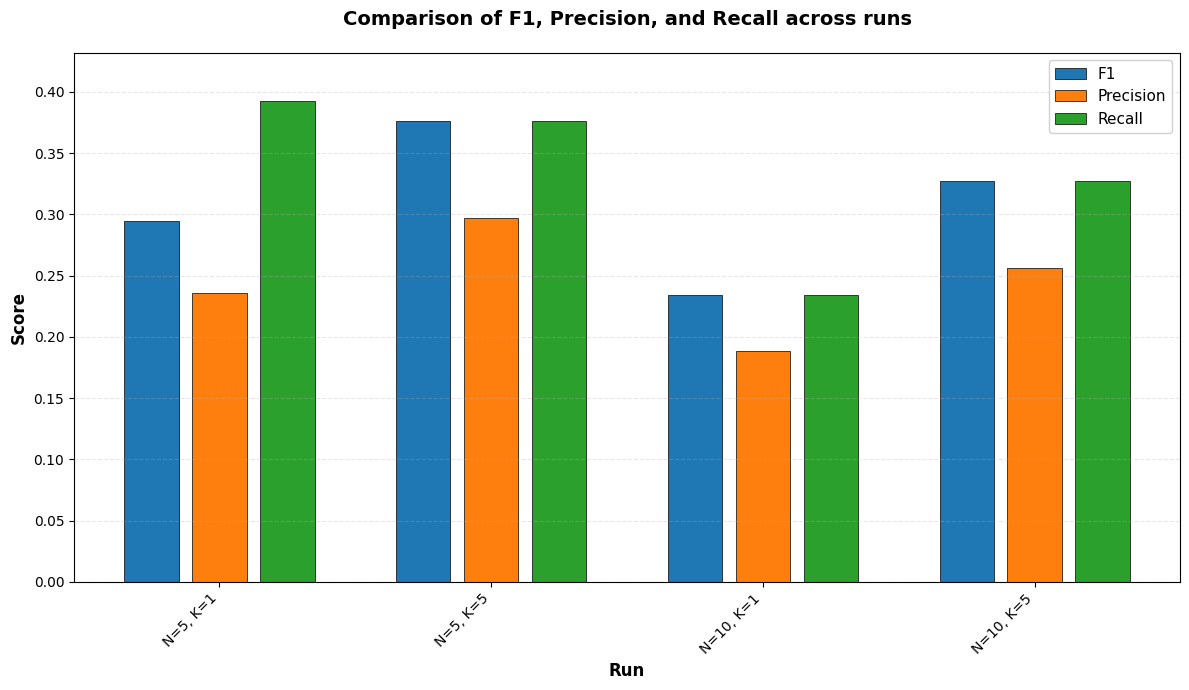

In [31]:
x = np.arange(len(run_name))
width = 0.2

plt.figure(figsize=(12, 7))
plt.bar(x - 0.25, test_f1, width, label="F1", color="C0", edgecolor="black", linewidth=0.5)
plt.bar(x, test_precision, width, label="Precision", color="C1", edgecolor="black", linewidth=0.5)
plt.bar(x + 0.25, test_recall, width, label="Recall", color="C2", edgecolor="black", linewidth=0.5)

plt.xlabel("Run", fontsize=12, fontweight="bold")
plt.ylabel("Score", fontsize=12, fontweight="bold")
plt.title("Comparison of F1, Precision, and Recall across runs", fontsize=14, fontweight="bold", pad=20)
plt.xticks(x, run_name, rotation=45, ha="right")
plt.ylim(0, max(max(test_f1), max(test_precision), max(test_recall)) * 1.1)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

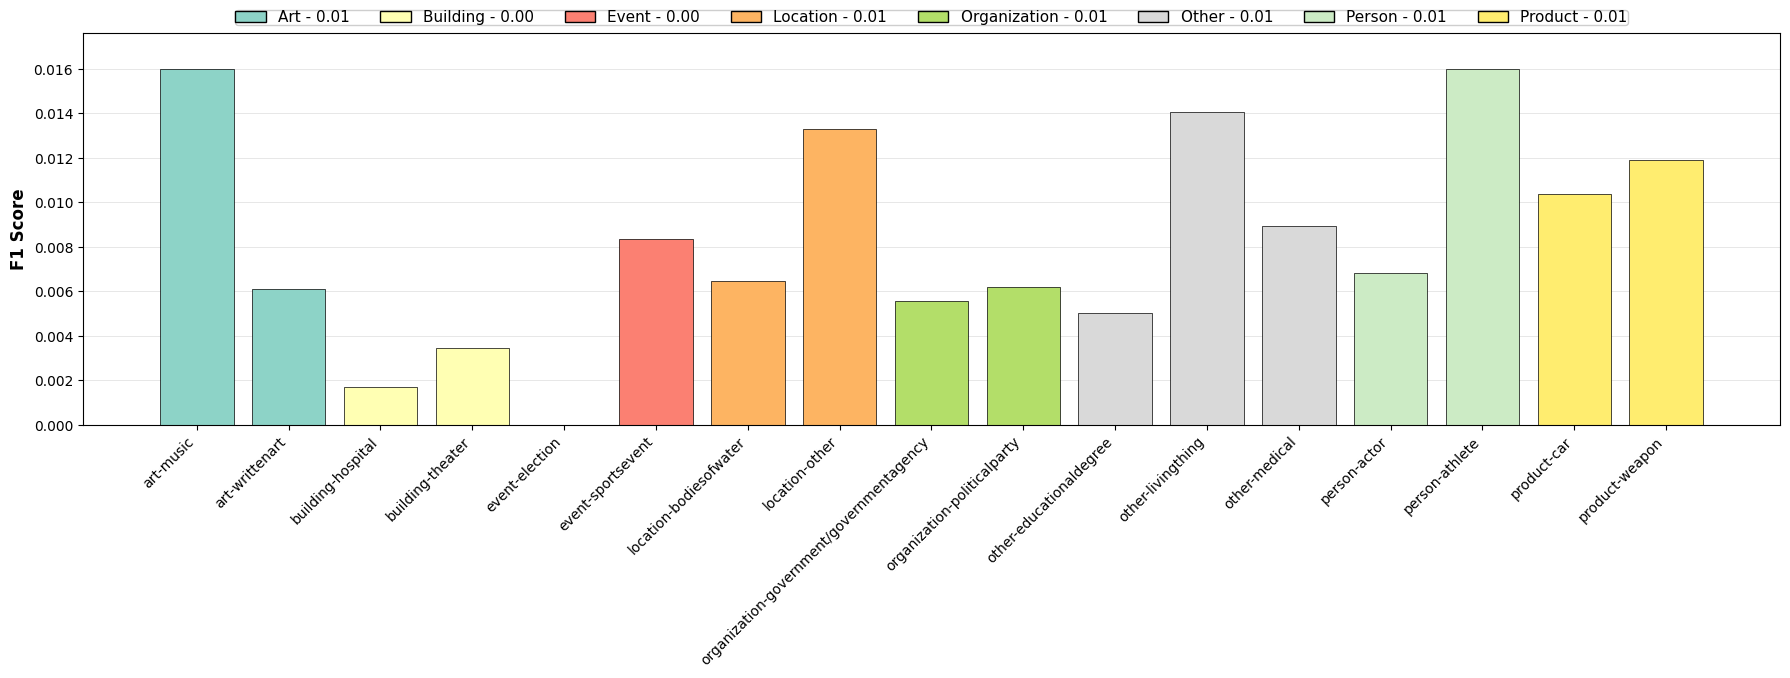

In [43]:
# Extract fine-grained types and their coarse parents
df_fine = df_5_1[df_5_1['type'].str.contains('-', na=False)].copy()
df_fine['coarse_type'] = df_fine['type'].str.split('-').str[0]

# Get coarse types and their F1 scores
df_coarse = df_5_1[~df_5_1['type'].str.contains('-', na=False) & (df_5_1['type'] != 'overall')].copy()
coarse_type_f1 = dict(zip(df_coarse['type'], df_coarse['f1']))

# Create color map
coarse_types = df_coarse['type'].values
colors = plt.cm.Set3(np.linspace(0, 1, len(coarse_types)))
color_map = {ct: colors[i] for i, ct in enumerate(coarse_types)}

# Create the plot
fig, ax = plt.subplots(figsize=(18, 7))
bars = ax.bar(range(len(df_fine)), df_fine['f1'], 
              color=[color_map[ct] for ct in df_fine['coarse_type']],
              edgecolor='black', linewidth=0.5)

# Create legend with coarse F1 scores from df
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[ct], edgecolor='black', 
                         label=f"{ct.capitalize()} - {coarse_type_f1[ct]:.2f}") 
                   for ct in coarse_types]
ax.legend(handles=legend_elements, fontsize=11, framealpha=0.95, ncol=8, loc='upper center', 
          bbox_to_anchor=(0.5, 1.08), borderpad=0)

ax.set_xticks(range(len(df_fine)))
ax.set_xticklabels(df_fine['type'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(df_fine['f1']) * 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()